# Day 3 — RSI·MACD 손계산 vs `ta` 라이브러리 대조

로직은 `src/indicators.py`에 있고, 이 노트북은 검증·대조·진단만 한다.

**오늘의 목적은 지표를 계산하는 것이 아니라 두 구현이 왜 다른지 밝히는 것이다.**
값이 다를 때 라이브러리가 옳다고 가정하지 않는다.

### `src/indicators.py`에 `shift`가 없는 이유

`diff` / `rolling` / `ewm` 은 전부 "현재와 과거"만 참조하므로 지표 계산 단계에서는
미래 참조가 원천적으로 발생할 수 없다. 진입 시점을 하루 늦추는 `shift(1)`은
**신호 단계(`signals.py`)의 책임**이며, 지표에 넣으면 손계산이 라이브러리보다
하루씩 밀려 존재하지 않는 차이를 진단하게 된다.

### 진행 순서

ta와 비교하는 것만으로는 "내 코드 버그"를 배제할 수 없다. 라이브러리가 틀렸을
수도 있기 때문이다. 그래서 **외부 라이브러리 없이 손계산이 옳음을 먼저 증명한
뒤에만** 대조로 넘어간다.

1. 자체 검증 5종 (외부 의존 없음)
2. 실데이터 계산 + `min_periods` 규약 대조
3. ta 대조 (1990년 전 구간)
4. 원인 진단 (로그 스케일 차이 시계열)
5. 결론

In [1]:
import sys
from importlib.metadata import version
from pathlib import Path

import numpy as np
import pandas as pd
import ta

PROJECT_ROOT = Path.cwd().parent  # -> Path (프로젝트 루트)
ROOT_TEXT = str(PROJECT_ROOT)     # -> str

if ROOT_TEXT not in sys.path:
    sys.path.insert(0, ROOT_TEXT)

from src import config, data, indicators

# 재현성: 라이브러리 버전이 바뀌면 기본값 동작이 달라질 수 있으므로 기록해둔다.
print(f"pandas  : {pd.__version__}")
print(f"numpy   : {np.__version__}")
print(f"ta      : {version('ta')}")
print()
print(f"RSI 기간           : {config.RSI_PERIOD}")
print(f"MACD fast/slow/sig : {config.MACD_FAST}/{config.MACD_SLOW}/{config.MACD_SIGNAL}")
print(f"EWM_ADJUST         : {config.EWM_ADJUST}  (pandas 기본값은 True — 명시적으로 고정)")
print(f"WILDER_SEED        : {config.WILDER_SEED!r}")
print(f"min_periods 규약   : {config.INDICATOR_MIN_PERIODS!r}")

pandas  : 3.0.5
numpy   : 2.5.1
ta      : 0.11.0

RSI 기간           : 14
MACD fast/slow/sig : 12/26/9
EWM_ADJUST         : False  (pandas 기본값은 True — 명시적으로 고정)
WILDER_SEED        : 'sma'
min_periods 규약   : 'window'


## 1. 자체 검증 — 외부 라이브러리 없이 손계산이 옳은가

ta와 값이 같다고 해서 내 코드가 옳은 것은 아니다. 둘 다 틀렸을 수도 있다.
아래 5개는 **지표의 정의만으로 정답을 미리 아는** 경우들이라, 외부 의존 없이
구현의 정오를 가릴 수 있다.

| # | 입력 | 정답 | 무엇을 잡아내는가 |
|---|---|---|---|
| 1 | 단조증가 1..200 | RSI = 100 | 하락분 분리, 0 분모 규약 |
| 2 | 단조감소 | RSI = 0 | 상승분 분리, 부호 처리 |
| 3 | 난수 시계열 | 두 공식 오차 < 1e-12 | RSI 대수 변형의 동치성 |
| 4 | 상수 시계열 | 0/0이 터지지 않음 | 규약대로 동작하는가 |
| 5 | MACD fast==slow | MACD선 = 0 | EMA 프리미티브 일관성 |

In [2]:
def make_test_frame(values, ticker="TEST"):
    """자체 검증용 long format DataFrame을 만든다.

    지표 함수는 (date, ticker, close)를 기대하므로 최소 스키마만 갖춘다.
    영업일 달력을 쓰는 이유는 실데이터와 형태를 맞추기 위해서일 뿐,
    검증 결과는 날짜에 의존하지 않는다.
    """
    count = len(values)                                        # -> int
    dates = pd.bdate_range("2000-01-03", periods=count)        # -> DatetimeIndex (count,)

    frame = pd.DataFrame(
        {
            "date": dates,
            "ticker": ticker,
            "close": np.asarray(values, dtype=float),
        }
    )  # -> DataFrame (count, 3)

    return frame


period = config.RSI_PERIOD  # -> int (14)
check_results = []          # -> list[dict], 검증 결과를 모아 마지막에 요약한다

In [3]:
# --- 검증 1: 단조증가 -> RSI = 100 ---
# 한 번도 내리지 않았으므로 평균 하락폭이 0이다. RS = 상승/0 = 무한대이고,
# RSI = 100 - 100/(1+무한대) = 100 으로 수렴한다. 0으로 나누는 자리라
# 규약을 잘못 두면 NaN이나 inf가 튀어나온다.

rising_values = np.arange(1, 201, dtype=float)  # -> ndarray[float] (200,)
rising_frame = make_test_frame(rising_values)   # -> DataFrame (200, 3)

rising_frame = indicators.rsi_simple(rising_frame)              # -> + rsi_simple_14
rising_frame = indicators.rsi_wilder(rising_frame)              # -> + rsi_wilder_14
rising_frame = indicators.rsi_wilder(rising_frame, seed="first")  # -> + rsi_wilder_14_first

print("검증 1 — 단조증가 시퀀스의 RSI는 100인가")

rising_ok = True  # -> bool

for column_name in ["rsi_simple_14", "rsi_wilder_14", "rsi_wilder_14_first"]:
    column = rising_frame[column_name]        # -> Series[float] (200,)
    valid = column.dropna()                   # -> Series[float] (워밍업 제외,)
    all_hundred = bool((valid == 100).all())  # -> bool

    if not all_hundred:
        rising_ok = False

    print(f"  {column_name:<22} 유효값 {len(valid):>3}개, 전부 100인가: {all_hundred}"
          f"  (min={valid.min():.6f}, max={valid.max():.6f})")

check_results.append({"검증": "1. 단조증가 -> 100", "통과": rising_ok})
print(f"  => {'통과' if rising_ok else '실패'}")

검증 1 — 단조증가 시퀀스의 RSI는 100인가
  rsi_simple_14          유효값 186개, 전부 100인가: True  (min=100.000000, max=100.000000)
  rsi_wilder_14          유효값 186개, 전부 100인가: True  (min=100.000000, max=100.000000)
  rsi_wilder_14_first    유효값 187개, 전부 100인가: True  (min=100.000000, max=100.000000)
  => 통과


In [4]:
# --- 검증 2: 단조감소 -> RSI = 0 ---
# 평균 상승폭이 0이므로 RS = 0, RSI = 100 - 100/(1+0) = 0 이다.
# 하락분을 양수로 뒤집는 처리가 틀렸다면 여기서 100이나 NaN이 나온다.

falling_values = np.arange(200, 0, -1, dtype=float)  # -> ndarray[float] (200,)
falling_frame = make_test_frame(falling_values)      # -> DataFrame (200, 3)

falling_frame = indicators.rsi_simple(falling_frame)
falling_frame = indicators.rsi_wilder(falling_frame)
falling_frame = indicators.rsi_wilder(falling_frame, seed="first")

print("검증 2 — 단조감소 시퀀스의 RSI는 0인가")

falling_ok = True  # -> bool

for column_name in ["rsi_simple_14", "rsi_wilder_14", "rsi_wilder_14_first"]:
    column = falling_frame[column_name]  # -> Series[float] (200,)
    valid = column.dropna()              # -> Series[float]
    all_zero = bool((valid == 0).all())  # -> bool

    if not all_zero:
        falling_ok = False

    print(f"  {column_name:<22} 유효값 {len(valid):>3}개, 전부 0인가: {all_zero}"
          f"  (min={valid.min():.6f}, max={valid.max():.6f})")

check_results.append({"검증": "2. 단조감소 -> 0", "통과": falling_ok})
print(f"  => {'통과' if falling_ok else '실패'}")

검증 2 — 단조감소 시퀀스의 RSI는 0인가
  rsi_simple_14          유효값 186개, 전부 0인가: True  (min=0.000000, max=0.000000)
  rsi_wilder_14          유효값 186개, 전부 0인가: True  (min=0.000000, max=0.000000)
  rsi_wilder_14_first    유효값 187개, 전부 0인가: True  (min=0.000000, max=0.000000)
  => 통과


In [5]:
# --- 검증 3: 두 대수 형태가 같은 값을 주는가 ---
# RSI는 흔히 두 형태로 쓰인다.
#
#   (A) RSI = 100 - 100 / (1 + U/D)
#   (B) RSI = 100 * U / (U + D)
#
# 대수적으로 같은 식이다. (A)의 분모에 U/D를 넣고 정리하면 (B)가 된다.
# 구현이 정의를 따랐다면 부동소수점 오차 수준에서 일치해야 한다.
# 일치하지 않으면 어딘가에서 정의를 잘못 옮긴 것이다.

generator = np.random.default_rng(config.RANDOM_SEED)  # -> Generator, 재현성 고정
steps = generator.normal(0, 1, size=500)               # -> ndarray[float] (500,)
walk_values = 100 + np.cumsum(steps)                   # -> ndarray[float] (500,), 랜덤워크

walk_frame = make_test_frame(walk_values)  # -> DataFrame (500, 3)

close_series = walk_frame["close"]                         # -> Series[float] (500,)
gain, loss = indicators.split_gain_loss(close_series)      # -> (Series, Series)

average_gain = indicators.wilder_rma(gain, period, seed="sma")  # -> Series[float] (500,)
average_loss = indicators.wilder_rma(loss, period, seed="sma")  # -> Series[float] (500,)

form_a = indicators.rsi_from_averages(average_gain, average_loss)  # -> Series[float] (500,)

denominator = average_gain + average_loss     # -> Series[float] (500,)
form_b = 100 * average_gain / denominator     # -> Series[float] (500,)

both_present = form_a.notna() & form_b.notna()  # -> Series[bool] (500,)
difference = (form_a - form_b).loc[both_present]  # -> Series[float]
max_difference = float(difference.abs().max())    # -> float

formula_ok = max_difference < 1e-12  # -> bool

print("검증 3 — RSI 두 대수 형태의 동치성")
print(f"  (A) 100 - 100/(1 + U/D)  vs  (B) 100 * U/(U+D)")
print(f"  비교 행 수 : {int(both_present.sum())}")
print(f"  최대 절대차: {max_difference:.6e}  (허용 1e-12)")

check_results.append({"검증": "3. 두 공식 동치", "통과": formula_ok})
print(f"  => {'통과' if formula_ok else '실패'}")

검증 3 — RSI 두 대수 형태의 동치성
  (A) 100 - 100/(1 + U/D)  vs  (B) 100 * U/(U+D)
  비교 행 수 : 486
  최대 절대차: 1.421085e-14  (허용 1e-12)
  => 통과


In [6]:
# --- 검증 4: 상수 시퀀스에서 0/0이 터지지 않는가 ---
# 가격이 전혀 움직이지 않으면 상승분도 하락분도 0이라 RS = 0/0 이 된다.
# 수학적으로 정의되지 않는 자리이므로 "규약"을 정해야 하고, 그 규약대로
# 동작하는지 확인해야 한다.
#
# 이 프로젝트 규약: 방향이 없으므로 중립값 50.
# ta 규약: emadn == 0 이면 무조건 100.
#
# 어느 쪽이 옳다기보다 **다르다는 사실을 알고 있어야** 한다. 실데이터에서
# 지수가 완전히 안 움직이는 날은 사실상 없어서 이 차이는 드러나지 않지만,
# 거래가 정지된 개별 종목으로 확장하면 실제로 부딪힌다.

flat_values = np.full(100, 50.0)      # -> ndarray[float] (100,)
flat_frame = make_test_frame(flat_values)  # -> DataFrame (100, 3)

flat_frame = indicators.rsi_simple(flat_frame)
flat_frame = indicators.rsi_wilder(flat_frame)

flat_close = flat_frame["close"]  # -> Series[float] (100,)
ta_flat = ta.momentum.RSIIndicator(close=flat_close, window=period, fillna=False).rsi()  # -> Series[float]

print("검증 4 — 상수 시퀀스 (0/0 구간)")

flat_ok = True  # -> bool

for column_name in ["rsi_simple_14", "rsi_wilder_14"]:
    column = flat_frame[column_name]  # -> Series[float] (100,)
    valid = column.dropna()           # -> Series[float]

    has_nan_after_warmup = bool(column.iloc[period:].isna().any())  # -> bool
    has_infinite = bool(np.isinf(valid).any())                       # -> bool
    unique_values = valid.unique()                                   # -> ndarray[float]

    exploded = has_nan_after_warmup or has_infinite  # -> bool

    if exploded:
        flat_ok = False

    print(f"  {column_name:<18} 값={unique_values}  NaN/inf 발생: {exploded}")

ta_valid = ta_flat.dropna()  # -> Series[float]
print(f"  {'ta_rsi':<18} 값={ta_valid.unique()}  <- 규약이 다름 (우리는 50, ta는 100)")

check_results.append({"검증": "4. 0/0 규약 동작", "통과": flat_ok})
print(f"  => {'통과' if flat_ok else '실패'} (터지지 않고 규약대로 동작)")

검증 4 — 상수 시퀀스 (0/0 구간)
  rsi_simple_14      값=[50.]  NaN/inf 발생: False
  rsi_wilder_14      값=[50.]  NaN/inf 발생: False
  ta_rsi             값=[100.]  <- 규약이 다름 (우리는 50, ta는 100)
  => 통과 (터지지 않고 규약대로 동작)


In [7]:
# --- 검증 5: MACD fast == slow 이면 MACD선은 항상 0 ---
# 같은 기간의 EMA 두 개를 빼는 것이므로 정확히 0이어야 한다. 0이 아니면
# ema() 프리미티브가 호출마다 다른 값을 내고 있다는 뜻이다.

macd_test_frame = make_test_frame(walk_values)  # -> DataFrame (500, 3)
macd_test_frame = indicators.macd(macd_test_frame, fast=period, slow=period, signal=config.MACD_SIGNAL)

macd_line = macd_test_frame["macd_line"]  # -> Series[float] (500,)
valid_line = macd_line.dropna()           # -> Series[float]

max_absolute = float(valid_line.abs().max())  # -> float
identical_ok = max_absolute == 0              # -> bool

print("검증 5 — MACD fast == slow 이면 MACD선 = 0")
print(f"  fast=slow={period}, 유효값 {len(valid_line)}개")
print(f"  최대 |MACD선| : {max_absolute:.6e}")

check_results.append({"검증": "5. fast==slow -> 0", "통과": identical_ok})
print(f"  => {'통과' if identical_ok else '실패'}")

검증 5 — MACD fast == slow 이면 MACD선 = 0
  fast=slow=14, 유효값 487개
  최대 |MACD선| : 0.000000e+00
  => 통과


In [8]:
# --- 자체 검증 종합 ---
check_frame = pd.DataFrame(check_results)  # -> DataFrame (5, 2)
all_passed = bool(check_frame["통과"].all())  # -> bool

print(check_frame.to_string(index=False))
print()

if all_passed:
    print("5종 전부 통과 — 외부 라이브러리 없이 손계산의 정합성이 확인됐다.")
    print("이제 ta 대조로 넘어간다.")
else:
    print("실패 항목이 있다. ta 대조로 넘어가지 말 것 —")
    print("차이가 나도 원인이 내 코드인지 라이브러리인지 가릴 수 없다.")

                검증   통과
    1. 단조증가 -> 100 True
      2. 단조감소 -> 0 True
        3. 두 공식 동치 True
      4. 0/0 규약 동작 True
5. fast==slow -> 0 True

5종 전부 통과 — 외부 라이브러리 없이 손계산의 정합성이 확인됐다.
이제 ta 대조로 넘어간다.


## 2. 실데이터 계산

손계산은 4가지를 만든다. 네 번째(`seed="first"`)는 대조 실험용이다 —
Wilder 평활은 그대로 두고 **시드만 바꾼** 버전이라, 이것이 ta와 일치하면
차이의 원인이 시드였다는 것이 증명된다.

`^SP500TR`도 함께 계산한다. 다만 이는 **`groupby("ticker")` 동작 확인용**이고,
신호에는 쓰지 않는다 (CLAUDE.md 규칙 5). 시각화는 `^GSPC`만 그린다.

In [9]:
df = data.load_parquet(config.RAW_OHLCV_PATH)  # -> DataFrame (18424, 8)

df = indicators.rsi_simple(df)                   # -> + rsi_simple_14
df = indicators.rsi_wilder(df)                   # -> + rsi_wilder_14        (시드 = 첫 14개 SMA)
df = indicators.rsi_wilder(df, seed="first")     # -> + rsi_wilder_14_first  (시드 = 첫 값)
df = indicators.macd(df)                         # -> + macd_line/signal/hist

added = [c for c in df.columns if "rsi" in c or "macd" in c]  # -> list[str] (6,)
print("손계산 컬럼:", added)
df.shape

2026-08-04 22:24:19,052 [INFO] 로드 완료: C:\Users\chris\projects\sp500-technical-strategy\data\raw\ohlcv_raw.parquet (18424행)


손계산 컬럼: ['rsi_simple_14', 'rsi_wilder_14', 'rsi_wilder_14_first', 'macd_line', 'macd_signal', 'macd_hist']


(18424, 14)

In [10]:
# ta 결과를 티커별로 계산해 붙인다.
# ta는 Series 하나만 받는 API라 티커 개념이 없다. 전체를 한 번에 넘기면
# ^GSPC 마지막 행과 ^SP500TR 첫 행이 이어져 계산된다. 지표도 diff/ewm이라
# 로그수익률과 똑같은 경계 문제를 갖는다.

ticker_column = df["ticker"]             # -> Series[str] (18424,)
unique_tickers = ticker_column.unique()  # -> ndarray[str] (2,)
tickers = sorted(unique_tickers)         # -> list[str] (2,)

pieces = []  # -> list[DataFrame]

for ticker in tickers:
    mask = ticker_column == ticker  # -> Series[bool] (18424,)
    subset = df.loc[mask]           # -> DataFrame (9212, 14)
    subset = subset.copy()          # -> DataFrame (9212, 14)

    close_series = subset["close"]  # -> Series[float] (9212,)

    rsi_indicator = ta.momentum.RSIIndicator(
        close=close_series,
        window=config.RSI_PERIOD,
        fillna=False,  # 라이브러리 기본값에 의존하지 않고 명시한다
    )  # -> RSIIndicator
    subset["ta_rsi"] = rsi_indicator.rsi()  # -> Series[float] (9212,)

    macd_indicator = ta.trend.MACD(
        close=close_series,
        window_fast=config.MACD_FAST,
        window_slow=config.MACD_SLOW,
        window_sign=config.MACD_SIGNAL,
        fillna=False,
    )  # -> MACD
    subset["ta_macd_line"] = macd_indicator.macd()           # -> Series[float] (9212,)
    subset["ta_macd_signal"] = macd_indicator.macd_signal()  # -> Series[float] (9212,)
    subset["ta_macd_hist"] = macd_indicator.macd_diff()      # -> Series[float] (9212,)

    pieces.append(subset)

both = pd.concat(pieces, ignore_index=True)  # -> DataFrame (18424, 18)
both = both.sort_values(["ticker", "date"])  # -> DataFrame (18424, 18)
both = both.reset_index(drop=True)           # -> DataFrame (18424, 18)

both.shape

(18424, 18)

### `min_periods` 규약 대조

**"이론적 워밍업 길이"라는 표현은 SMA에만 쓸 수 있다.** SMA는 창을 채울 값이
실제로 없어서 앞의 (n-1)개가 수학적으로 정의되지 않는다.

반면 **EMA와 Wilder 평활은 재귀식이라 워밍업 경계가 수학적으로 없다.** 첫 값부터
계속 값이 나온다. 따라서 "선행 NaN이 몇 개인가"는 이론값이 아니라 우리가 정한
`min_periods` 규약(`config.INDICATOR_MIN_PERIODS = "window"`)의 결과다.

아래는 **이론값과의 대조가 아니라 규약과의 대조**다.

In [11]:
rsi_n = config.RSI_PERIOD    # -> int (14)
fast_n = config.MACD_FAST    # -> int (12)
slow_n = config.MACD_SLOW    # -> int (26)
signal_n = config.MACD_SIGNAL  # -> int (9)

# 규약: min_periods = 창 길이. 즉 창 길이만큼 관측치가 쌓이면 값을 낸다.
convention = {
    "rsi_simple_14": (rsi_n, "SMA 수학적 경계 (diff 1 + 창 13) — 이론값"),
    "rsi_wilder_14": (rsi_n, "규약: 시드가 첫 14개 SMA라 index=14부터"),
    "rsi_wilder_14_first": (rsi_n - 1, "규약: min_periods=14, 단 diff 첫 NaN이 0.0이라 한 칸 당겨짐"),
    "ta_rsi": (rsi_n - 1, "ta 동작: 위와 동일 (같은 부작용)"),
    "macd_line": (slow_n - 1, "규약: 느린 EMA min_periods=26"),
    "ta_macd_line": (slow_n - 1, "ta 동작: 동일"),
    "macd_signal": (slow_n - 1 + signal_n - 1, "규약: MACD선 시작 + 시그널 EMA min_periods=9"),
    "ta_macd_signal": (slow_n - 1 + signal_n - 1, "ta 동작: 동일"),
}  # -> dict[str, tuple[int, str]] (8,)

print("규약 대조 — 선행 NaN 개수가 config.INDICATOR_MIN_PERIODS 규약과 맞는가")
print()

convention_ok = True  # -> bool

for ticker in tickers:
    mask = both["ticker"] == ticker         # -> Series[bool] (18424,)
    subset = both.loc[mask]                 # -> DataFrame (9212, 18)
    subset = subset.reset_index(drop=True)  # -> DataFrame (9212, 18)

    print(f"  {ticker}")

    for column_name in convention:
        expected, reason = convention[column_name]  # -> (int, str)
        column = subset[column_name]                # -> Series[float] (9212,)
        actual = int(column.isna().sum())           # -> int
        matched = actual == expected                # -> bool

        if not matched:
            convention_ok = False

        status = "OK" if matched else "불일치"
        print(f"    {column_name:<22} 실측 {actual:<3} 규약 {expected:<3} {status:<5} {reason}")

    print()

print(f"  => {'통과' if convention_ok else '실패'}")

규약 대조 — 선행 NaN 개수가 config.INDICATOR_MIN_PERIODS 규약과 맞는가

  ^GSPC
    rsi_simple_14          실측 14  규약 14  OK    SMA 수학적 경계 (diff 1 + 창 13) — 이론값
    rsi_wilder_14          실측 14  규약 14  OK    규약: 시드가 첫 14개 SMA라 index=14부터
    rsi_wilder_14_first    실측 13  규약 13  OK    규약: min_periods=14, 단 diff 첫 NaN이 0.0이라 한 칸 당겨짐
    ta_rsi                 실측 13  규약 13  OK    ta 동작: 위와 동일 (같은 부작용)
    macd_line              실측 25  규약 25  OK    규약: 느린 EMA min_periods=26
    ta_macd_line           실측 25  규약 25  OK    ta 동작: 동일
    macd_signal            실측 33  규약 33  OK    규약: MACD선 시작 + 시그널 EMA min_periods=9
    ta_macd_signal         실측 33  규약 33  OK    ta 동작: 동일

  ^SP500TR
    rsi_simple_14          실측 14  규약 14  OK    SMA 수학적 경계 (diff 1 + 창 13) — 이론값
    rsi_wilder_14          실측 14  규약 14  OK    규약: 시드가 첫 14개 SMA라 index=14부터
    rsi_wilder_14_first    실측 13  규약 13  OK    규약: min_periods=14, 단 diff 첫 NaN이 0.0이라 한 칸 당겨짐
    ta_rsi                 실측 13  규약 13  OK    ta 동작: 위와 동일 (같은 부작용)
    macd_l

In [12]:
# 우리 규약과 ta 동작이 갈리는 지점을 명시적으로 기록한다.
print("규약 차이 기록 — 우리 구현 vs ta")
print()
print("  1) RSI 유효 시작 위치")
print(f"     rsi_wilder_14 (Wilder 원전, SMA 시드) : index {rsi_n}")
print(f"     ta_rsi                                : index {rsi_n - 1}")
print("     원인: ta는 diff의 첫 NaN을 where(diff>0, 0.0)로 0.0으로 바꾼다.")
print("           NaN > 0 이 False로 평가되기 때문이고, 의도된 설계라기보다")
print("           where의 부작용에 가깝다. 그 0.0이 시드가 되어 한 칸 당겨진다.")
print()
print("  2) 0/0 구간 규약 (자체검증 4)")
print("     우리: 50 (방향 없음 = 중립)")
print("     ta  : 100 (emadn == 0 이면 무조건 100)")
print()
print("  3) 중간 NaN 여부 — 첫 유효값 이후 구멍이 있으면 재귀가 끊긴 것이다")

hole_ok = True  # -> bool

for ticker in tickers:
    mask = both["ticker"] == ticker         # -> Series[bool] (18424,)
    subset = both.loc[mask]                 # -> DataFrame (9212, 18)
    subset = subset.reset_index(drop=True)  # -> DataFrame (9212, 18)

    for column_name in convention:
        column = subset[column_name]              # -> Series[float] (9212,)
        first_valid = column.first_valid_index()  # -> int
        after_start = column.iloc[first_valid:]   # -> Series[float]
        hole_count = int(after_start.isna().sum())  # -> int

        if hole_count > 0:
            hole_ok = False
            print(f"     {ticker} {column_name}: 중간 NaN {hole_count}개")

print(f"     => {'중간 NaN 없음' if hole_ok else '구멍 발견 — 확인 필요'}")

규약 차이 기록 — 우리 구현 vs ta

  1) RSI 유효 시작 위치
     rsi_wilder_14 (Wilder 원전, SMA 시드) : index 14
     ta_rsi                                : index 13
     원인: ta는 diff의 첫 NaN을 where(diff>0, 0.0)로 0.0으로 바꾼다.
           NaN > 0 이 False로 평가되기 때문이고, 의도된 설계라기보다
           where의 부작용에 가깝다. 그 0.0이 시드가 되어 한 칸 당겨진다.

  2) 0/0 구간 규약 (자체검증 4)
     우리: 50 (방향 없음 = 중립)
     ta  : 100 (emadn == 0 이면 무조건 100)

  3) 중간 NaN 여부 — 첫 유효값 이후 구멍이 있으면 재귀가 끊긴 것이다
     => 중간 NaN 없음


## 3. ta 대조 (1990년 전 구간)

대조는 분석 구간(2000~)이 아니라 **수집 구간 전체(1990~)** 에서 한다.
시드 차이는 1990년대 초반에 나타나므로, 2000년부터 자르면 원인 진단에
필요한 증거가 통째로 사라진다.

In [13]:
pairs = [
    ("rsi_simple_14", "ta_rsi", "RSI 단순SMA vs ta"),
    ("rsi_wilder_14", "ta_rsi", "RSI Wilder(SMA시드) vs ta"),
    ("rsi_wilder_14_first", "ta_rsi", "RSI Wilder(첫값시드) vs ta"),
    ("macd_line", "ta_macd_line", "MACD선 vs ta"),
    ("macd_signal", "ta_macd_signal", "MACD 시그널선 vs ta"),
    ("macd_hist", "ta_macd_hist", "MACD 히스토그램 vs ta"),
]  # -> list[tuple[str, str, str]] (6,)

summary, details = indicators.comparison_table(both, pairs)  # -> (DataFrame (12, 6), DataFrame)

summary

,ticker,comparison,n_compared,max_abs_diff,mean_abs_diff,worst_date
0,^GSPC,RSI 단순SMA vs ta,9198,30.011444,6.271549,2025-05-09
1,^SP500TR,RSI 단순SMA vs ta,9198,29.996822,6.261795,2025-05-09
2,^GSPC,RSI Wilder(SMA시드) vs ta,9198,4.340107,0.010762,1990-02-07
3,^SP500TR,RSI Wilder(SMA시드) vs ta,9198,4.340563,0.011130,1990-02-07
4,^GSPC,RSI Wilder(첫값시드) vs ta,9199,0.000000,0.000000,NaT
5,^SP500TR,RSI Wilder(첫값시드) vs ta,9199,0.000000,0.000000,NaT
6,^GSPC,MACD선 vs ta,9187,0.000000,0.000000,NaT
7,^SP500TR,MACD선 vs ta,9187,0.000000,0.000000,NaT
8,^GSPC,MACD 시그널선 vs ta,9179,0.000000,0.000000,NaT
9,^SP500TR,MACD 시그널선 vs ta,9179,0.000000,0.000000,NaT


In [14]:
# 차이가 가장 큰 날짜들. **언제** 차이가 나는지가 원인 진단의 핵심 단서다.
# 초반에 몰려 있으면 시드 문제, 전 구간에 흩어져 있으면 평활 방식이 다르다.

signal_ticker = config.TICKERS["signal"]          # -> str ("^GSPC")
detail_mask = details["ticker"] == signal_ticker  # -> Series[bool]
signal_details = details.loc[detail_mask]         # -> DataFrame

signal_details

,comparison,date,ticker,value_a,value_b,abs_diff
0,RSI 단순SMA vs ta,2025-05-09,^GSPC,87.480813,57.469369,30.011444
1,RSI 단순SMA vs ta,2001-10-11,^GSPC,86.275718,56.438228,29.837490
2,RSI 단순SMA vs ta,1992-10-29,^GSPC,92.642889,63.018136,29.624752
3,RSI 단순SMA vs ta,2011-04-05,^GSPC,88.834096,60.252494,28.581602
4,RSI 단순SMA vs ta,1998-10-28,^GSPC,87.712622,59.413289,28.299333
10,RSI Wilder(SMA시드) vs ta,1990-02-07,^GSPC,39.697682,44.037789,4.340107
11,RSI Wilder(SMA시드) vs ta,1990-02-09,^GSPC,40.016728,44.201252,4.184524
12,RSI Wilder(SMA시드) vs ta,1990-02-05,^GSPC,34.359064,38.488979,4.129915
13,RSI Wilder(SMA시드) vs ta,1990-02-08,^GSPC,38.810093,42.870045,4.059952
14,RSI Wilder(SMA시드) vs ta,1990-02-02,^GSPC,32.620466,36.459849,3.839383


### 정밀도 확인 — "0.000000"이 반올림인가 진짜 0인가

위 표의 `0.000e+00`은 소수 표시라 **반올림일 수도 있다.** 2.8e-16도 소수 6자리로는
0.000000으로 보인다. 그런데 이 구분이 결론을 바꾼다.

| 실제 값 | 결론 |
|---|---|
| 정확히 0 | **비트 단위 일치** — 같은 부동소수점 연산을 같은 순서로 수행 |
| 1e-16 수준 | **부동소수점 오차 수준의 일치** — 식은 같고 연산 순서만 다름 |
| 그 이상 | 실질적 차이 — 가정이 다르거나 코드가 틀림 |

`(a) 코드 버그 / (b) 가정 차이 / (c) 부동소수점` 판정의 근거로 쓰려면 이 셋을
섞으면 안 된다. `np.array_equal`과 `(diff != 0).sum()`으로 직접 확인한다.

In [15]:
precision_targets = [
    ("rsi_wilder_14_first", "ta_rsi", "RSI Wilder(첫값시드)"),
    ("rsi_wilder_14", "ta_rsi", "RSI Wilder(SMA시드)"),
    ("rsi_simple_14", "ta_rsi", "RSI 단순SMA"),
    ("macd_line", "ta_macd_line", "MACD선"),
    ("macd_signal", "ta_macd_signal", "MACD 시그널선"),
    ("macd_hist", "ta_macd_hist", "MACD 히스토그램"),
]  # -> list[tuple[str, str, str]] (6,)

precision_mask = both["ticker"] == signal_ticker  # -> Series[bool] (18424,)
precision_df = both.loc[precision_mask]           # -> DataFrame (9212, 18)

precision_rows = []  # -> list[dict]

for column_a, column_b, label in precision_targets:
    result = indicators.precision_check(precision_df[column_a], precision_df[column_b])  # -> dict
    result["지표"] = label
    precision_rows.append(result)

precision_frame = pd.DataFrame(precision_rows)  # -> DataFrame (6, 7)

print(f"정밀도 확인 — {signal_ticker}, 1990년 전 구간")
print()

for row_index in precision_frame.index:
    label = precision_frame.loc[row_index, "지표"]                    # -> str
    max_absolute = precision_frame.loc[row_index, "max_abs_diff"]     # -> float
    n_nonzero = precision_frame.loc[row_index, "n_nonzero"]           # -> int
    arrays_equal = precision_frame.loc[row_index, "array_equal"]      # -> bool
    nan_equal = precision_frame.loc[row_index, "nan_positions_equal"]  # -> bool
    verdict = precision_frame.loc[row_index, "verdict"]               # -> str

    print(f"  {label}")
    print(f"    np.abs(diff).max()  : {max_absolute:.6e}")
    print(f"    (diff != 0).sum()   : {n_nonzero:,}")
    print(f"    np.array_equal      : {arrays_equal}")
    print(f"    NaN 위치까지 동일   : {nan_equal}")
    print(f"    => {verdict}")
    print()

정밀도 확인 — ^GSPC, 1990년 전 구간

  RSI Wilder(첫값시드)
    np.abs(diff).max()  : 0.000000e+00
    (diff != 0).sum()   : 0
    np.array_equal      : True
    NaN 위치까지 동일   : True
    => 비트 단위 일치 (정확히 0)

  RSI Wilder(SMA시드)
    np.abs(diff).max()  : 4.340107e+00
    (diff != 0).sum()   : 523
    np.array_equal      : False
    NaN 위치까지 동일   : False
    => 실질적 차이 — 원인 규명 필요

  RSI 단순SMA
    np.abs(diff).max()  : 3.001144e+01
    (diff != 0).sum()   : 9,198
    np.array_equal      : False
    NaN 위치까지 동일   : False
    => 실질적 차이 — 원인 규명 필요

  MACD선
    np.abs(diff).max()  : 0.000000e+00
    (diff != 0).sum()   : 0
    np.array_equal      : True
    NaN 위치까지 동일   : True
    => 비트 단위 일치 (정확히 0)

  MACD 시그널선
    np.abs(diff).max()  : 0.000000e+00
    (diff != 0).sum()   : 0
    np.array_equal      : True
    NaN 위치까지 동일   : True
    => 비트 단위 일치 (정확히 0)

  MACD 히스토그램
    np.abs(diff).max()  : 0.000000e+00
    (diff != 0).sum()   : 0
    np.array_equal      : True
    NaN 위치까지 동일   : True
    => 비트 단위 

## 4. 원인 진단

### 진단 1 — ta는 어떤 평활 방식을 쓰는가

후보는 셋이다. 같은 "14일"이라도 평활 계수가 다르다.

| 후보 | 평활 계수 | 성격 |
|---|---|---|
| 단순이동평균(SMA) | 최근 14개 균등 | 15개 전 값의 무게가 갑자기 0 |
| Wilder 평활(RMA) | `alpha = 1/14 ≈ 0.0714` | 지수 감쇠, 과거가 사라지지 않음 |
| 일반 EMA | `alpha = 2/15 ≈ 0.1333` | Wilder보다 최근 값에 약 2배 민감 |

세 후보 모두 **시드를 첫 값으로 통일**해서 만든다. 그래야 시드가 아니라
**평활 계수만** 다른 상태에서 비교되어, 어느 것이 ta인지 깨끗하게 갈린다.

In [16]:
# 일반 EMA(alpha = 2/(n+1)) 버전 RSI를 진단용으로 만든다.
# 프로젝트가 쓸 지표가 아니라 "후보 소거"용 실험이라 src/에 두지 않고
# indicators.py의 프리미티브를 조립해서 여기서만 쓴다.

print(f"Wilder alpha = 1/{rsi_n}     = {1 / rsi_n:.6f}")
print(f"EMA    alpha = 2/{rsi_n + 1} = {2 / (rsi_n + 1):.6f}")
print()

ema_pieces = []  # -> list[DataFrame]

for ticker in tickers:
    mask = both["ticker"] == ticker  # -> Series[bool] (18424,)
    subset = both.loc[mask]          # -> DataFrame (9212, 18)
    subset = subset.copy()           # -> DataFrame (9212, 18)

    close_series = subset["close"]                         # -> Series[float] (9212,)
    gain, loss = indicators.split_gain_loss(close_series)  # -> (Series, Series)

    # ta와 같은 출발 조건(첫 값 0.0)을 주어 평활 계수만 다르게 만든다.
    gain = gain.copy()  # -> Series[float]
    loss = loss.copy()  # -> Series[float]
    gain.iloc[0] = 0.0
    loss.iloc[0] = 0.0

    average_gain = indicators.ema(gain, rsi_n)  # -> Series[float], alpha = 2/(n+1)
    average_loss = indicators.ema(loss, rsi_n)  # -> Series[float]

    subset["rsi_ema_14"] = indicators.rsi_from_averages(average_gain, average_loss)  # -> Series[float]
    ema_pieces.append(subset)

diagnostic = pd.concat(ema_pieces, ignore_index=True)    # -> DataFrame (18424, 19)
diagnostic = diagnostic.sort_values(["ticker", "date"])  # -> DataFrame
diagnostic = diagnostic.reset_index(drop=True)           # -> DataFrame

candidate_pairs = [
    ("rsi_simple_14", "ta_rsi", "후보1 단순SMA"),
    ("rsi_wilder_14_first", "ta_rsi", "후보2 Wilder(alpha=1/14)"),
    ("rsi_ema_14", "ta_rsi", "후보3 일반EMA(alpha=2/15)"),
]  # -> list[tuple] (3,)

candidate_summary, _ = indicators.comparison_table(diagnostic, candidate_pairs)  # -> DataFrame (6, 6)

print("진단 1 판정 — ta가 쓰는 평활 방식")
print()

for row_index in candidate_summary.index:
    ticker = candidate_summary.loc[row_index, "ticker"]  # -> str

    if ticker != signal_ticker:
        continue

    label = candidate_summary.loc[row_index, "comparison"]            # -> str
    max_absolute = candidate_summary.loc[row_index, "max_abs_diff"]   # -> float

    if max_absolute == 0:
        conclusion = "<<< 일치 — ta는 이 방식이다"  # -> str
    else:
        conclusion = "불일치 (소거)"                # -> str

    print(f"  {label:<28} 최대 절대차 {max_absolute:.6e}  {conclusion}")

Wilder alpha = 1/14     = 0.071429
EMA    alpha = 2/15 = 0.133333

진단 1 판정 — ta가 쓰는 평활 방식

  후보1 단순SMA                    최대 절대차 3.001144e+01  불일치 (소거)
  후보2 Wilder(alpha=1/14)       최대 절대차 0.000000e+00  <<< 일치 — ta는 이 방식이다
  후보3 일반EMA(alpha=2/15)        최대 절대차 1.764994e+01  불일치 (소거)


### 진단 2 — 차이의 시간 구조로 원인을 가른다

**"차이가 작다"는 진단이 아니다.** 차이가 시간에 따라 어떻게 변하는가가 원인을
가른다. 판정 기준을 아래로 고정한다.

| 차이의 시간 구조 | 원인 |
|---|---|
| 1990년대 초반에만 크고 지수적으로 0에 수렴 | **초기값 씨딩 차이** |
| 2000년 이후에도 일정 크기 유지 | **평활 방식 자체가 다름** |
| 1e-12 수준에서 무작위로 흔들림 | **부동소수점 오차** |
| 특정 날짜에만 튀거나 계단식으로 변함 | **코드 버그** (해당 날짜 원본 확인) |

`rsi_simple`과 `rsi_wilder` 중 **어느 쪽이 수렴하고 어느 쪽이 유지되는지의 대비**로
ta의 평활 방식을 판정한다. y축은 반드시 로그 스케일이어야 한다 — 선형이면 초반
큰 값에 눌려 2000년 이후가 바닥에 붙어 수렴/유지를 구분할 수 없다.

In [17]:
diagnosis_rows = []  # -> list[dict]

for column_a, label in [("rsi_simple_14", "단순SMA"), ("rsi_wilder_14", "Wilder(SMA시드)")]:
    for ticker in tickers:
        verdict = indicators.classify_difference(both, column_a, "ta_rsi", ticker)  # -> dict
        verdict["라벨"] = label
        diagnosis_rows.append(verdict)

diagnosis = pd.DataFrame(diagnosis_rows)  # -> DataFrame (4, 8)
show_columns = ["ticker", "라벨", "early_max", "late_max", "late_mean", "verdict"]  # -> list[str] (6,)

diagnosis[show_columns]

,ticker,라벨,early_max,late_max,late_mean,verdict
0,^GSPC,단순SMA,29.624752,30.011444,6.199353,평활 방식 자체가 다름 (2000년 이후에도 유지)
1,^SP500TR,단순SMA,29.981846,29.996822,6.193905,평활 방식 자체가 다름 (2000년 이후에도 유지)
2,^GSPC,Wilder(SMA시드),4.340107,0.000000,0.000000,초기값 씨딩 차이 (지수적으로 수렴)
3,^SP500TR,Wilder(SMA시드),4.340563,0.000000,0.000000,초기값 씨딩 차이 (지수적으로 수렴)


그림 저장: C:\Users\chris\projects\sp500-technical-strategy\figures\day03_seed_convergence.png


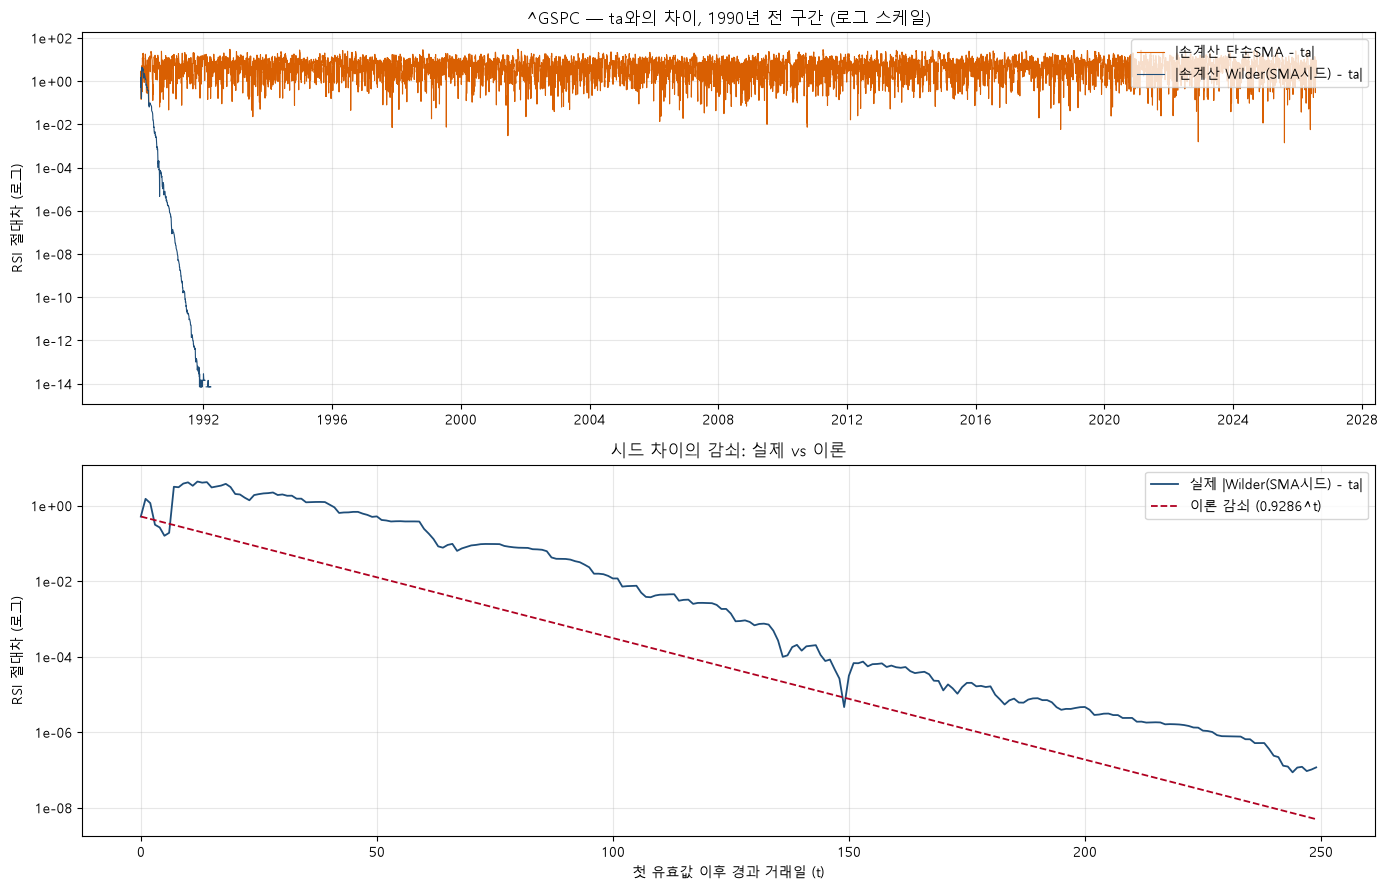

In [18]:
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

matplotlib.rcParams["font.family"] = "Malgun Gothic"  # 윈도우 한글 폰트 (없으면 네모로 깨짐)
matplotlib.rcParams["axes.unicode_minus"] = False     # 한글 폰트에는 유니코드 마이너스 글리프가 없다

signal_mask = both["ticker"] == signal_ticker  # -> Series[bool] (18424,)
signal_df = both.loc[signal_mask]              # -> DataFrame (9212, 18)
signal_df = signal_df.sort_values("date")      # -> DataFrame (9212, 18)
signal_df = signal_df.reset_index(drop=True)   # -> DataFrame (9212, 18)

ta_series = signal_df["ta_rsi"]  # -> Series[float] (9212,)


def absolute_difference_series(column_name):
    """ta와의 절대차 시계열. 로그축에 0은 그릴 수 없으므로 NaN으로 바꾼다."""
    column = signal_df[column_name]                  # -> Series[float] (9212,)
    both_present = column.notna() & ta_series.notna()  # -> Series[bool] (9212,)

    difference = (column - ta_series).abs()  # -> Series[float] (9212,)
    difference = difference.where(both_present)  # -> Series[float], 비교 불가 구간은 NaN
    difference = difference.replace(0.0, np.nan)  # -> Series[float], 로그축에 0은 못 그린다

    return difference


simple_difference = absolute_difference_series("rsi_simple_14")  # -> Series[float]
wilder_difference = absolute_difference_series("rsi_wilder_14")  # -> Series[float]

figure, axes = plt.subplots(2, 1, figsize=(14, 9))

plot_date = signal_df["date"]  # -> Series[datetime64]

axes[0].plot(plot_date, simple_difference, linewidth=0.8, color="#d95f02",
             label="|손계산 단순SMA - ta|")
axes[0].plot(plot_date, wilder_difference, linewidth=0.8, color="#1f4e79",
             label="|손계산 Wilder(SMA시드) - ta|")
axes[0].set_yscale("log")
# 로그축 눈금은 mathtext로 그려지는데, 한글 폰트에 유니코드 마이너스가 없어
# 지수 표기가 깨진다. ASCII 하이픈을 쓰는 포맷터로 바꿔 회피한다.
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f"{value:.0e}"))
axes[0].set_ylabel("RSI 절대차 (로그)")
axes[0].set_title(f"{signal_ticker} — ta와의 차이, 1990년 전 구간 (로그 스케일)")
axes[0].grid(alpha=0.3, which="both")
axes[0].legend(loc="upper right")

# 아래 패널: 시드 차이가 이론 곡선 (1-1/n)^t 를 따라가는지 확대해서 본다.
wilder_valid = wilder_difference.dropna()  # -> Series[float]
zoom_length = 250                           # -> int, 확대할 거래일 수
zoom_values = wilder_valid.iloc[:zoom_length]  # -> Series[float] (250,)

steps = np.arange(len(zoom_values))              # -> ndarray[int] (250,)
decay_base = 1 - 1 / rsi_n                       # -> float (13/14)
first_difference = float(zoom_values.iloc[0])    # -> float
theoretical = first_difference * (decay_base ** steps)  # -> ndarray[float] (250,)

axes[1].plot(steps, zoom_values.to_numpy(), linewidth=1.3, color="#1f4e79",
             label="실제 |Wilder(SMA시드) - ta|")
axes[1].plot(steps, theoretical, linewidth=1.3, color="#b00020", linestyle="--",
             label=f"이론 감쇠 ({decay_base:.4f}^t)")
axes[1].set_yscale("log")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda value, _: f"{value:.0e}"))
axes[1].set_xlabel("첫 유효값 이후 경과 거래일 (t)")
axes[1].set_ylabel("RSI 절대차 (로그)")
axes[1].set_title("시드 차이의 감쇠: 실제 vs 이론")
axes[1].grid(alpha=0.3, which="both")
axes[1].legend(loc="upper right")

figure.tight_layout()
figure.savefig(config.SEED_CONVERGENCE_FIGURE_PATH,
               dpi=config.FIGURE_DPI, bbox_inches=config.FIGURE_BBOX)
print(f"그림 저장: {config.SEED_CONVERGENCE_FIGURE_PATH}")

plt.show()

In [19]:
# 시드 차이가 임계값 아래로 내려가기까지 며칠이 걸리는지 수치로 낸다.
print("진단 2 — 시드 차이의 감쇠 속도")
print(f"  첫 비교 시점 차이: {first_difference:.6f} (RSI 눈금 0~100 기준)")
print()

thresholds = [1.0, 0.1, 0.01, 1e-6, 1e-10]  # -> list[float] (5,)
wilder_array = wilder_valid.to_numpy()      # -> ndarray[float]

for threshold in thresholds:
    below = wilder_array < threshold            # -> ndarray[bool]
    below_positions = np.flatnonzero(below)     # -> ndarray[int]

    if len(below_positions) == 0:
        print(f"  {threshold:>8.0e} 아래로: 표본 구간 내 미도달")
        continue

    first_below = int(below_positions[0])  # -> int
    print(f"  {threshold:>8.0e} 아래로: {first_below}거래일 후 (약 {first_below / 21:.1f}개월)")

print()
print("  (13/14)^t 는 어떤 t에서도 정확히 0이 아니다 — 배정밀도 한계에서 멈춘다.")
print("  반면 단순SMA와의 차이는 아래 수치처럼 2000년 이후에도 유지된다:")

simple_late = simple_difference.loc[signal_df["date"] >= pd.Timestamp("2000-01-01")]  # -> Series[float]
print(f"    |단순SMA - ta| 2000년 이후 평균: {simple_late.mean():.4f}, 최대: {simple_late.max():.4f}")

진단 2 — 시드 차이의 감쇠 속도
  첫 비교 시점 차이: 0.514678 (RSI 눈금 0~100 기준)

     1e+00 아래로: 0거래일 후 (약 0.0개월)
     1e-01 아래로: 63거래일 후 (약 3.0개월)
     1e-02 아래로: 102거래일 후 (약 4.9개월)
     1e-06 아래로: 228거래일 후 (약 10.9개월)
     1e-10 아래로: 348거래일 후 (약 16.6개월)

  (13/14)^t 는 어떤 t에서도 정확히 0이 아니다 — 배정밀도 한계에서 멈춘다.
  반면 단순SMA와의 차이는 아래 수치처럼 2000년 이후에도 유지된다:
    |단순SMA - ta| 2000년 이후 평균: 6.1994, 최대: 30.0114


## 5. 시각화 — 국면 확대 (`^GSPC`만)

시드 차이가 사라진 뒤 구간에서는 Wilder와 ta가 사실상 겹친다. 그 상태에서
**단순SMA 버전만 따로 노는지**를 눈으로 확인한다.

그림 저장: C:\Users\chris\projects\sp500-technical-strategy\figures\day03_rsi_comparison.png


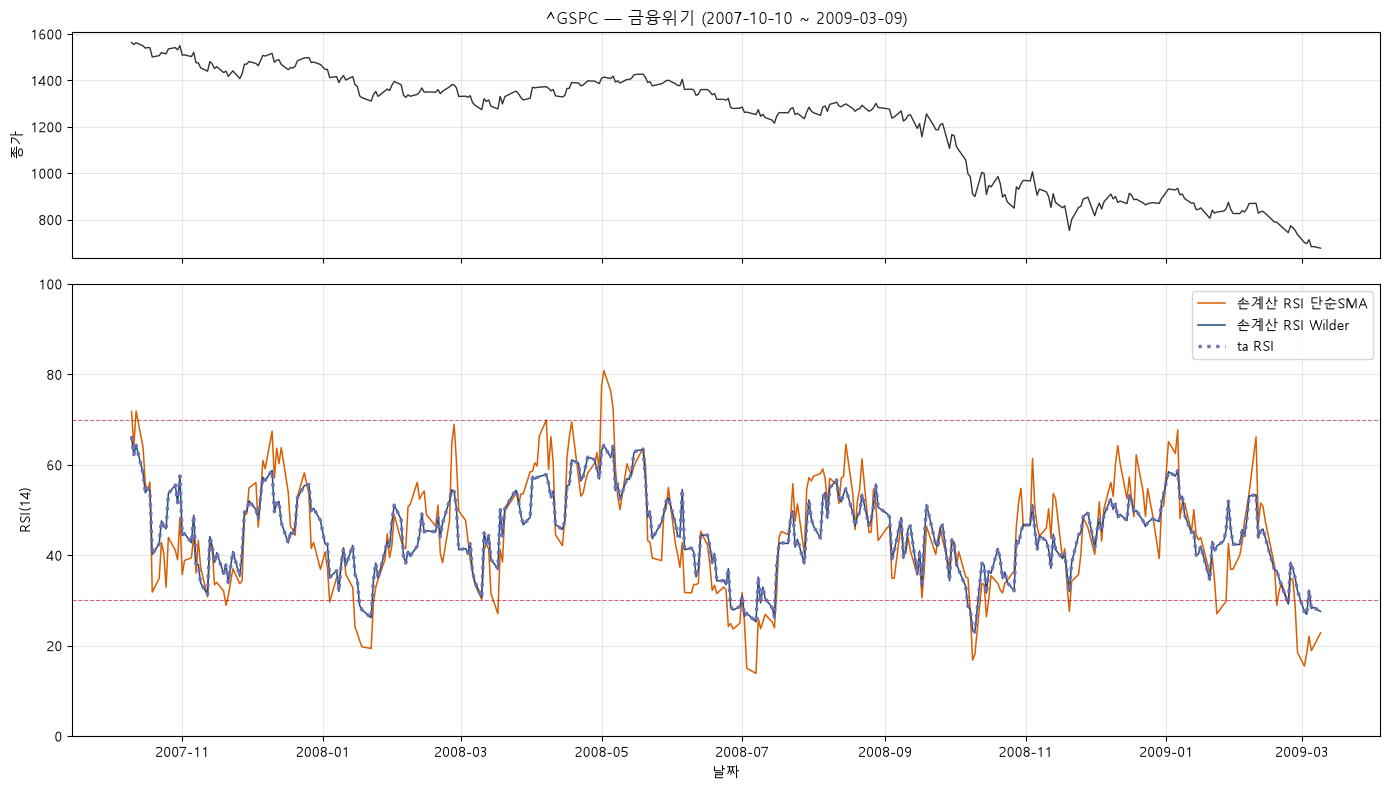

In [20]:
zoom_key = config.INDICATOR_ZOOM_PHASE          # -> str ("financial_crisis")
zoom_info = config.MARKET_REGIMES[zoom_key]    # -> dict
zoom_start = pd.Timestamp(zoom_info["start"])  # -> Timestamp
zoom_end = pd.Timestamp(zoom_info["end"])      # -> Timestamp

date_column = signal_df["date"]      # -> Series[datetime64] (9212,)
after_start = date_column >= zoom_start  # -> Series[bool] (9212,)
before_end = date_column <= zoom_end     # -> Series[bool] (9212,)
in_zoom = after_start & before_end        # -> Series[bool] (9212,)

zoom_df = signal_df.loc[in_zoom]          # -> DataFrame (국면 행 수, 18)
zoom_df = zoom_df.reset_index(drop=True)  # -> DataFrame (국면 행 수, 18)

figure, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True,
                            gridspec_kw={"height_ratios": [1, 2]})

zoom_x = zoom_df["date"]  # -> Series[datetime64]

axes[0].plot(zoom_x, zoom_df["close"], linewidth=1.0, color="#333333")
axes[0].set_ylabel("종가")
axes[0].set_title(f"{signal_ticker} — {zoom_info['name']} ({zoom_info['start']} ~ {zoom_info['end']})")
axes[0].grid(alpha=0.3)

axes[1].plot(zoom_x, zoom_df["rsi_simple_14"], linewidth=1.1, color="#d95f02",
             label="손계산 RSI 단순SMA")
axes[1].plot(zoom_x, zoom_df["rsi_wilder_14"], linewidth=1.1, color="#1f4e79",
             label="손계산 RSI Wilder")
axes[1].plot(zoom_x, zoom_df["ta_rsi"], linewidth=2.4, color="#7570b3",
             linestyle=":", label="ta RSI")

axes[1].axhline(70, color="#b00020", linestyle="--", linewidth=0.8, alpha=0.6)
axes[1].axhline(30, color="#b00020", linestyle="--", linewidth=0.8, alpha=0.6)
axes[1].set_ylabel(f"RSI({rsi_n})")
axes[1].set_xlabel("날짜")
axes[1].set_ylim(0, 100)
axes[1].grid(alpha=0.3)
axes[1].legend(loc="upper right")

figure.tight_layout()
figure.savefig(config.RSI_COMPARE_FIGURE_PATH,
               dpi=config.FIGURE_DPI, bbox_inches=config.FIGURE_BBOX)
print(f"그림 저장: {config.RSI_COMPARE_FIGURE_PATH}")

plt.show()

In [21]:
# 확대 구간 안에서만 다시 대조한다. 시드 영향이 완전히 사라진 구간이므로
# 여기서 남는 차이는 시드 때문이 아니다.
zoom_pairs = [
    ("rsi_simple_14", "ta_rsi", f"[{zoom_info['name']}] 단순SMA vs ta"),
    ("rsi_wilder_14", "ta_rsi", f"[{zoom_info['name']}] Wilder vs ta"),
]  # -> list[tuple] (2,)

zoom_summary, _ = indicators.comparison_table(zoom_df, zoom_pairs)  # -> DataFrame (2, 6)
zoom_summary

,ticker,comparison,n_compared,max_abs_diff,mean_abs_diff,worst_date
0,^GSPC,[금융위기] 단순SMA vs ta,355,16.589868,4.933349,2007-12-14
1,^GSPC,[금융위기] Wilder vs ta,355,0.000000,0.000000,NaT


## 6. 신호 불일치 분해 — "72% 어긋난다"는 무엇을 뭉갠 숫자인가

"최대 절대차 30"은 감이 오지 않는다. 이 프로젝트가 실제로 쓸 것은 RSI 값이
아니라 **70/30 임계선을 넘었는가**라는 이진 신호이므로, 신호 기준으로 환산해야
의미가 생긴다.

그런데 **"신호의 72%가 어긋난다"는 문장도 그대로 쓸 수 없다.** 성격이 다른 세
상황을 한 숫자로 뭉갠 것이기 때문이다.

| 상황 | 올바른 서술 |
|---|---|
| (A) 한쪽이 훨씬 자주 발동 | "평활 방식이 발동 빈도를 N배 바꾼다" |
| (B) 같은 사건을 며칠 어긋나 포착 | "지연(lag) 차이" |
| (C) 서로 다른 사건을 가리킴 | "신호가 서로 다른 것을 탐지한다" |

셋을 갈라야 결론 문장을 쓸 수 있다. 아래에서 분해한다.

In [22]:
# 분석 구간(2000~)에서만 본다. 시드 영향은 이 구간에서 이미 정확히 0이므로,
# 여기서 갈리는 것은 순수하게 평활 방식 차이 때문이다.

analysis_start = pd.Timestamp(config.ANALYSIS_START)  # -> Timestamp
in_analysis = signal_df["date"] >= analysis_start     # -> Series[bool] (9212,)
analysis_df = signal_df.loc[in_analysis]              # -> DataFrame (분석 구간 행 수, 18)
analysis_df = analysis_df.reset_index(drop=True)      # -> DataFrame (분석 구간 행 수, 18)

simple_rsi = analysis_df["rsi_simple_14"]  # -> Series[float] (분석 구간 행 수,)
wilder_rsi = analysis_df["rsi_wilder_14"]  # -> Series[float] (분석 구간 행 수,)

thresholds = [
    (config.RSI_OVERSOLD, "below", f"과매도 (RSI < {config.RSI_OVERSOLD})"),
    (config.RSI_OVERBOUGHT, "above", f"과매수 (RSI > {config.RSI_OVERBOUGHT})"),
]  # -> list[tuple[int, str, str]] (2,)

disagreement_results = []  # -> list[tuple[str, dict]]

for threshold, direction, name in thresholds:
    simple_signal = indicators.threshold_signal(simple_rsi, threshold, direction)  # -> Series[float]
    wilder_signal = indicators.threshold_signal(wilder_rsi, threshold, direction)  # -> Series[float]

    decomposed = indicators.decompose_disagreement(
        simple_signal,
        wilder_signal,
        label_a="단순SMA",
        label_b="Wilder",
    )  # -> dict

    disagreement_results.append((name, decomposed))

print(f"분석 구간 {config.ANALYSIS_START} ~ , {signal_ticker}")
print(f"타이밍 허용 범위 ±{config.SIGNAL_TIMING_TOLERANCE}거래일")
print()

for name, result in disagreement_results:
    print(f"[{name}]")
    print(f"  판단 가능일        : {result['n_days']:,}")
    print(f"  단순SMA 발동       : {result['n_a']:,}일 ({result['rate_a']:.1f}%)")
    print(f"  Wilder 발동        : {result['n_b']:,}일 ({result['rate_b']:.1f}%)")
    print(f"  빈도비 (SMA/Wilder): {result['frequency_ratio']:.2f}배")
    print(f"  혼동행렬  둘 다={result['both']:,}  SMA만={result['only_a']:,}"
          f"  Wilder만={result['only_b']:,}  둘 다 아님={result['neither']:,}")
    print(f"  Wilder 신호가 SMA에 포함된 비율: {result['containment_b_in_a']:.1f}%")
    print(f"  분해  SMA만: 타이밍={result['only_a_timing']:,} / 진짜={result['only_a_true']:,}"
          f"   |  Wilder만: 타이밍={result['only_b_timing']:,} / 진짜={result['only_b_true']:,}")
    print(f"  표면 불일치율 {result['raw_disagreement_pct']:.1f}%"
          f"  ->  진짜 불일치율 {result['true_disagreement_pct']:.1f}%")
    print()

분석 구간 2000-01-01 ~ , ^GSPC
타이밍 허용 범위 ±3거래일

[과매도 (RSI < 30)]
  판단 가능일        : 6,684
  단순SMA 발동       : 392일 (5.9%)
  Wilder 발동        : 126일 (1.9%)
  빈도비 (SMA/Wilder): 3.11배
  혼동행렬  둘 다=114  SMA만=278  Wilder만=12  둘 다 아님=6,280
  Wilder 신호가 SMA에 포함된 비율: 90.5%
  분해  SMA만: 타이밍=80 / 진짜=198   |  Wilder만: 타이밍=9 / 진짜=3
  표면 불일치율 71.8%  ->  진짜 불일치율 49.8%

[과매수 (RSI > 70)]
  판단 가능일        : 6,684
  단순SMA 발동       : 1,184일 (17.7%)
  Wilder 발동        : 426일 (6.4%)
  빈도비 (SMA/Wilder): 2.78배
  혼동행렬  둘 다=358  SMA만=826  Wilder만=68  둘 다 아님=5,432
  Wilder 신호가 SMA에 포함된 비율: 84.0%
  분해  SMA만: 타이밍=237 / 진짜=589   |  Wilder만: 타이밍=51 / 진짜=17
  표면 불일치율 71.4%  ->  진짜 불일치율 48.4%



In [23]:
# 리포트 붙여넣기용 마크다운 표
disagreement_table = indicators.disagreement_to_markdown(disagreement_results)  # -> str
print(disagreement_table)

**1) 발동 빈도**

| 신호 | 판단 가능일 | A 발동 | A 비율 | B 발동 | B 비율 | 빈도비 A/B |
|---|---|---|---|---|---|---|
| 과매도 (RSI < 30) | 6,684 | 392 | 5.9% | 126 | 1.9% | **3.11배** |
| 과매수 (RSI > 70) | 6,684 | 1,184 | 17.7% | 426 | 6.4% | **2.78배** |

**2) 혼동행렬과 포함 관계**

| 신호 | 둘 다 | A만 | B만 | 둘 다 아님 | 비대칭 A만:B만 | B가 A에 포함된 비율 |
|---|---|---|---|---|---|---|
| 과매도 (RSI < 30) | 114 | 278 | 12 | 6,280 | **23.2 : 1** | **90.5%** |
| 과매수 (RSI > 70) | 358 | 826 | 68 | 5,432 | **12.1 : 1** | **84.0%** |

**3) 타이밍 차이 vs 진짜 불일치**

| 신호 | A만 (타이밍) | A만 (진짜) | B만 (타이밍) | B만 (진짜) | 표면 불일치율 | 진짜 불일치율 |
|---|---|---|---|---|---|---|
| 과매도 (RSI < 30) | 80 | 198 | 9 | 3 | 71.8% | **49.8%** |
| 과매수 (RSI > 70) | 237 | 589 | 51 | 17 | 71.4% | **48.4%** |

> **읽는 법**
> - '타이밍'은 상대 신호가 ±3거래일 이내에 존재하는 경우다 (같은 사건을 며칠 어긋나 잡음). '진짜'는 그 범위에 상대 신호가 없는 경우다.
> - 타이밍 판정에는 `rolling(center=True)`가 쓰인다. 이는 **미래를 참조**하므로 사후 분석 전용이며 매매 규칙에 들어갈 수 없다.
> - 빈도비가 1에서 크게 벗어나면, 불일치의 주된 원인은 '서로 다른 사건을 가리킨다'가 아니라 '한쪽이 훨씬 자주 발동한다'이다.


## 7. 대조 결과표 (리포트 붙여넣기용)

In [24]:
markdown_table = indicators.comparison_to_markdown(summary)  # -> str
print(markdown_table)

| 티커 | 비교 | 비교행수 | 최대 절대차 | 평균 절대차 | 최대차 발생일 | 판정 |
|---|---|---|---|---|---|---|
| ^GSPC | RSI 단순SMA vs ta | 9,198 | 3.001e+01 | 6.272e+00 | 2025-05-09 | 구현 차이 — 규명 필요 |
| ^SP500TR | RSI 단순SMA vs ta | 9,198 | 3.000e+01 | 6.262e+00 | 2025-05-09 | 구현 차이 — 규명 필요 |
| ^GSPC | RSI Wilder(SMA시드) vs ta | 9,198 | 4.340e+00 | 1.076e-02 | 1990-02-07 | 구현 차이 — 규명 필요 |
| ^SP500TR | RSI Wilder(SMA시드) vs ta | 9,198 | 4.341e+00 | 1.113e-02 | 1990-02-07 | 구현 차이 — 규명 필요 |
| ^GSPC | RSI Wilder(첫값시드) vs ta | 9,199 | 0.000e+00 | 0.000e+00 | - | 완전 동일 |
| ^SP500TR | RSI Wilder(첫값시드) vs ta | 9,199 | 0.000e+00 | 0.000e+00 | - | 완전 동일 |
| ^GSPC | MACD선 vs ta | 9,187 | 0.000e+00 | 0.000e+00 | - | 완전 동일 |
| ^SP500TR | MACD선 vs ta | 9,187 | 0.000e+00 | 0.000e+00 | - | 완전 동일 |
| ^GSPC | MACD 시그널선 vs ta | 9,179 | 0.000e+00 | 0.000e+00 | - | 완전 동일 |
| ^SP500TR | MACD 시그널선 vs ta | 9,179 | 0.000e+00 | 0.000e+00 | - | 완전 동일 |
| ^GSPC | MACD 히스토그램 vs ta | 9,179 | 0.000e+00 | 0.000e+00 | - | 완전 동일 |
| ^SP500TR | MACD 히스

In [25]:
saved_path = config.INDICATOR_DIFF_CSV_PATH  # -> Path
summary.to_csv(saved_path, index=False, encoding="utf-8-sig")
print(f"저장 완료: {saved_path} ({len(summary)}행)")

저장 완료: C:\Users\chris\projects\sp500-technical-strategy\reports\day03_indicator_diff.csv (12행)


## 결론

### 1. ta가 쓰는 평활 방식은 Wilder 평활(alpha = 1/14)이다

시드를 첫 값으로 통일해 **평활 계수만** 다르게 한 뒤 비교한 결과:

| 후보 | 최대 절대차 | 판정 |
|---|---|---|
| 단순SMA | 30.01 | 소거 |
| **Wilder (alpha = 1/14)** | **0.000000** | **일치** |
| 일반 EMA (alpha = 2/15) | 17.65 | 소거 |

`ta.momentum.RSIIndicator`는 내부적으로 `ewm(alpha=1/window, adjust=False)`를
쓴다. `ewm`이라는 이름 때문에 일반 EMA처럼 보이지만 계수가 `1/n`이므로 Wilder
평활이다. 일반 EMA의 `2/(n+1)`과 헷갈리면 안 된다.

### 2. "0.000000"은 반올림이 아니라 **비트 단위 일치**다

정밀도를 지수 표기로 직접 확인했다.

| 비교 | `np.abs(diff).max()` | `(diff != 0).sum()` | `np.array_equal` | 결론 |
|---|---|---|---|---|
| Wilder(첫값시드) vs ta | `0.000000e+00` | 0 | **True** | 비트 단위 일치 |
| MACD선 vs ta | `0.000000e+00` | 0 | **True** | 비트 단위 일치 |
| MACD 시그널선 vs ta | `0.000000e+00` | 0 | **True** | 비트 단위 일치 |
| MACD 히스토그램 vs ta | `0.000000e+00` | 0 | **True** | 비트 단위 일치 |
| 단순SMA vs ta | `3.001144e+01` | 9,198 | False | 실질적 차이 |
| 일반EMA vs ta | `1.764994e+01` | 9,199 | False | 실질적 차이 |

NaN 위치까지 동일하다. 즉 "오차 수준에서 비슷하다"가 아니라 **같은 부동소수점
연산을 같은 순서로 수행한 결과**다. 이 구분이 있어야 아래 (c) 배제가 성립한다.

#### Wilder(SMA시드)의 nonzero가 523개뿐인 이유 — "수렴"이 아니다

비교 가능한 9,198행 중 차이가 0이 아닌 행은 **523개**뿐이고, **1992-03-27부터
표본 끝(2026-07-31)까지 단 한 행도 0이 아닌 곳이 없다.** 마지막으로 0이 아니었던
1992-03-26의 차이는 `7.105427e-15`였다.

이것을 "0에 수렴한다"고 쓰면 부정확하다. 수렴은 한없이 가까워지되 도달하지는
않는 것을 뜻하는데, 여기서 실제로 일어난 일은 다르다.

1. 시드 차이가 `(13/14)^t` 로 줄어들다가, 두 평균값의 차이가 **그 크기에서
   float64가 구분할 수 있는 최소 간격(1 ULP) 아래로 떨어졌다.**
2. 그 순간 두 평균은 **같은 float64 비트 패턴**이 된다.
3. 이후로는 같은 값이 같은 재귀식에 들어가 같은 연산을 거치므로, 결과도 반드시
   같은 비트가 나온다. **두 시계열은 다시 갈라질 수 없다.**

즉 근사적으로 가까워진 상태가 아니라 **완전히 같은 상태로 흡수된 것**이다.
이것이 위 표에서 `array_equal`이 아니라 `(diff != 0).sum()`을 함께 봐야 하는
이유다 — 앞부분 523행 때문에 `array_equal`은 False지만, 그 뒤는 완전히 같다.

#### 이 결과가 1990년부터 수집한 설계 결정을 정당화한다

차이가 사라진 1992-03-27은 **분석 구간 시작(2000-01-01)보다 7년 9개월 앞선다.**
분석 구간의 6,684거래일 전체에서 시드 선택의 영향은 **정확히 0**이다.

`config.COLLECT_START = 1990`과 `ANALYSIS_START = 2000`을 나눈 것은 원래
"200일 이동평균 워밍업 확보"가 명목이었는데, 오늘 그 결정이 **정량적 근거**를
얻었다. 만약 2000년부터 수집했다면 분석 구간 초반 약 2년이 시드 관례에 따라
달라졌을 것이고, 그 구간은 닷컴 붕괴 국면과 정확히 겹친다.

### 3. 남은 차이의 원인은 (b) 가정 차이 — 버그도 부동소수점도 아니다

| 비교 | 1995년 이전 최대 | 2000년 이후 평균 | 시간 구조 | 원인 |
|---|---|---|---|---|
| Wilder(첫값시드) vs ta | 0.000000 | 0.000000 | — | 차이 없음 |
| Wilder(SMA시드) vs ta | 4.34 | **0.000000** | 지수적 수렴 | **초기값 씨딩 차이** |
| 단순SMA vs ta | 29.62 | **6.20** | 전 구간 유지 | **평활 방식 차이** |
| MACD 3종 vs ta | 0.000000 | 0.000000 | — | 차이 없음 |

**(a) 내 코드 버그는 배제됐다.** 외부 라이브러리 없이 도는 자체검증 5종이
전부 통과했고(단조증가→100, 단조감소→0, 두 대수 형태 오차 1.42e-14, 0/0 규약
동작, fast==slow→0), 결정적으로 **시드만 바꾼 버전이 ta와 비트 단위로
일치**했다. 평활 로직 자체에 오류가 있었다면 시드를 바꾼다고 0이 될 수 없다.

**(c) 부동소수점 오차도 아니다.** MACD 3종은 `np.array_equal`이 True인 정확한
0이고, Wilder 시드 차이는 1992-03-27에 두 시계열이 비트 단위로 동일해진 뒤
표본 끝까지 갈라지지 않는다. (위 그림 상단에서 파란 선이 1992년경 사라지는 것은
데이터가 없어서가 아니라 차이가 정확히 0이 되어 로그축에 그릴 수 없기 때문이다.)

시드 차이의 감쇠는 `(13/14)^t` 를 따른다 — 0.51에서 출발해 0.01 아래로
102거래일, 1e-10 아래로 348거래일, 그리고 523거래일째에 float64 정밀도 아래로
떨어져 소멸했다.

### 4. 표준 구현: `rsi_wilder(seed="sma")`

- RSI의 원래 정의(Wilder 1978)이고, ta가 쓰는 평활 계수와 같다
- 시드 차이는 분석 구간 시작(2000-01-01) 훨씬 전에 배정밀도 0이 되므로,
  이 선택이 분석 결과에 미치는 영향은 **없다**
- `seed="first"`는 ta/pandas 호환을 확인하는 스위치로 남겨둔다
- MACD는 손계산과 ta가 완전히 같으므로 어느 쪽을 써도 무방하다

**`rsi_simple`은 "RSI"로 쓰지 않는다.** 다만 삭제하지 않고 남긴다 — 평활 선택이
결과를 얼마나 바꾸는지 보여주는 증거이기 때문이다.

### 5. 이 대조에서 가장 중요한 결과 — 불일치의 정체는 "빈도 차이"다

표면 불일치율은 71.8% / 71.4%지만, **이 숫자를 그대로 쓰면 안 된다.** 분해하면
정체가 드러난다.

| 항목 | 과매도 (< 30) | 과매수 (> 70) |
|---|---|---|
| 단순SMA 발동 | 392일 (5.9%) | 1,184일 (17.7%) |
| Wilder 발동 | 126일 (1.9%) | 426일 (6.4%) |
| **빈도비** | **3.11배** | **2.78배** |
| SMA만 : Wilder만 | **23.2 : 1** | **12.1 : 1** |
| Wilder 신호가 SMA에 포함된 비율 | **90.5%** | **84.0%** |
| 표면 불일치율 | 71.8% | 71.4% |
| 진짜 불일치율 (±3일 보정 후) | 49.8% | 48.4% |

**결론: "두 신호가 서로 다른 사건을 가리킨다"는 서술은 틀렸다.**

1. **주된 원인은 (A) 빈도 차이다.** 단순SMA가 Wilder보다 약 3배 자주 발동한다.
   Wilder(14)는 지수평활로 치면 span 27 상당이라 훨씬 둔하기 때문이다.
2. **비대칭이 결정적이다.** 과매도에서 "SMA만 발동"이 278일인데 "Wilder만
   발동"은 12일뿐이다(23:1). 그리고 **Wilder 신호의 90.5%는 SMA도 함께
   발동**한다. 즉 Wilder의 신호 집합은 SMA 신호 집합의 **거의 부분집합**이다.
3. **(B) 타이밍 차이는 일부에 그친다.** SMA 단독 발동 278일 중 ±3거래일 이내에
   Wilder 신호가 있는 것은 80일(29%)이다. 나머지 198일은 Wilder가 아예 반응하지
   않은 얕은 하락이다.
4. 따라서 올바른 서술은 **"평활 방식이 신호 발동 빈도를 약 3배 바꾸며, 둔한
   구현의 신호는 민감한 구현의 부분집합에 가깝다"** 이다.

#### 판단 유보 — 어느 쪽이 나은지는 아직 알 수 없다

**SMA 단독 신호 198일(Wilder가 반응하지 않은 얕은 하락)이 노이즈인지 유효
신호인지는 본 대조로 판정할 수 없다.** 신호 후 수익률 분포(8/5 이벤트 스터디)와
거래비용 손익분기 분석(8/14)에서 검증한다.

이 점을 분명히 해둔다: 신호 개수가 3배 다르면 거래 횟수가 3배 달라지고
**수수료·슬리피지 총액도 3배 달라진다.** 그러나 이것은 **"Wilder가 우월하다"는
뜻이 아니다.** 비용이 3배라도 추가 신호 198일의 기대수익이 그 비용을 넘으면
단순SMA가 낫다. 지금 확인된 것은 **비용 구조가 다르다는 사실**뿐이고, 순손익
비교는 이벤트 스터디와 손익분기 분석을 거쳐야 가능하다. 비용만 보고 둔한 지표를
고르는 것은 "거래를 안 하면 수수료가 0"이라는 동어반복에 빠지는 길이다.

#### 부수 관찰 — 과매수 발동률 17.7%

**단순SMA 기준 과매수(RSI > 70) 발동률이 17.7%로, 과매수를 예외적 상태로 보는
통상적 해석과 맞지 않는다.** 6거래일 중 하루꼴이면 "예외"라고 부르기 어렵다.
26년간 우상향한 지수에서 RSI 분포 자체가 위로 치우쳤을 가능성이 있다. Wilder
기준으로도 6.4%로 과매도(1.9%)의 3배가 넘어 같은 방향의 비대칭이 보인다.
**8/5에 국면별 RSI 분포를 확인한다** — 임계선 70/30을 대칭으로 두는 것이
타당한지가 여기서 갈린다.

### 6. 명세의 재현 불가능성

> **"RSI(14) < 30"이라는 명세는 재현 가능하지 않다.**
> 평활 방식(simple / Wilder / EMA)과 초기값 씨딩 방식까지 적어야 비로소 신호가
> 특정된다.
> → 내일(8/5) `docs/signal_spec.md`에 반영한다.

2단계에서 Backtrader와 결과가 어긋난다면 가장 먼저 확인할 지점이 여기다.

### 다음에 확인할 것

- Backtrader의 RSI가 어떤 평활·시드를 쓰는지 (`SmoothedMovingAverage` 계열로
  알려져 있으나 직접 확인해야 한다)
- ta의 0/0 규약(100)과 우리 규약(50) 차이는 지수에서는 드러나지 않는다.
  개별 종목(거래정지일 존재)으로 확장할 때 실제 문제가 된다.
- 빈도 차이가 국면별로도 유지되는지 (H2와 연결 — 변동성이 3.3배 다른 국면에서
  고정 임계선이 어떻게 반응하는가)

---

**내 해석 (직접 채울 것):**
